<a href="https://colab.research.google.com/github/gu12934/Data_614_Final_project/blob/main/Data614_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# --------------- Start of Project --------------

# incorporate info from paper
- then brainstomr and look at all eda adn get the code from here and put it into kaggle and see what ML i can do
- add the relevant results and outputs and make a discussion section and interpretation


:Project requirements

- Projects include finding a data sets (or using your own), forming questions to ask from the data,
solving the business problem and providing suggestions, and presenting it in the class. Students
are required to communicate regularly with the instructor on what they are planning to do, as
early as possible. Each team will submit the following:
- Written report. Please try to limit this to 10 single spaced letter size pages including tables,
figures, and references. You do not need to fill all pages to have a good project. In fact, if
your project is unnecessarily long, it will reduce its clarity (one of the criteria for grading).
- Data used in the project, preferably in a commonly-used format.
- Codes used to derive the results, properly commented and complete. It should be
executable on the data without the need to change anything in the code using the dataset
and get all the results in the report.
- Presentation file. You will present your project at the last class

1. Context
- Companies manage dozens of simultaneous projects, each with overlapping teams, consultants, phases, and external dependencies. Despite the scale and complexity of this work, most firms still rely on experience and intuition when estimating how long a project will take or how much it will cost.

- This project proposes using historical project data to build a predictive system that forecasts cost overruns and schedule delays before they materialize. Unlike the stock market or retail demand pivots — which are analytically sound but domain-generic — the firm framing provides a specific, defensible domain with a built-in narrative: every percentage point of cost overrun represents real financial loss for a real firm.

- This places AI automation at the centre of the project rather than treating it as an afterthought, and it incorporates text analytics as a core component by using a language model to extract structured features from unstructured project briefs.


2. Research Questions
Primary Questions
1.	What time-series patterns exist in project spend and milestone completion rates across different project types and phases? (Using STL decomposition, rolling statistics, ACF/PACF analysis)
2.	Can we forecast whether a project will exceed its budget or miss its deadline, and by how much? (ARIMA, ETS, STL + regression models)
3.	Which project-level factors most strongly predict cost overruns and schedule delays? (Regression with external regressors: team size, project type, permit complexity, number of change orders)
4.	Can an AI automation layer extract structured risk features from a plain-text project brief and generate a real-time risk assessment? (LLM-based text extraction + forecasting model integration)


- B. Supplementary Dataset — Kaggle Construction Project Management
Source: kaggle.com/datasets/programmer3/construction-project-management-dataset

- Variables include:
•	Schedule, cost, and risk data from real projects
•	Team size, contractor type, project scope
•	Risk scores and change order counts

- Adds richness to the primary dataset with project-level features that NYC data may not capture granularly.


# concepts covered in class

- Module 1: Introduction, EDA
module: contains 0 sub-modules
6
- Module 2: Classification
module: contains 0 sub-modules
2
- Module 3: Tree-Based Models and Validation
module: contains 0 sub-modules
3
- Module 4: Unsupervised Learning
module: contains 0 sub-modules
5
- Module 5: Time-Series
module: contains 1 sub-modules
7
- Module 6: Cloud Computing and Power BI
module: contains 0 sub-modules
4
- Module 7: ML and AI
module: contains 1 sub-modules
9
- Module 8: SVM
module: contains 1 sub-modules
4
- Module 9: Text Analytics
module: contains 2 sub-modules



- https://www.kaggle.com/code/gurmolsingh/data614-construction/edit

other insights:
- https://www.kaggle.com/code/wellcum/construction-project-management-analysis

- https://www.kaggle.com/code/salemnka/predictive-analytics-on-the-construction-project

- it has random forest training

data
- https://www.kaggle.com/datasets/programmer3/construction-project-management-dataset

# ------------ start of code in python------------

# data types and infomration
Task_ID

Task_Duration_Days

Labor_Required

Equipment_Units

Material_Cost_USD

Start_Constraint

Risk_Level

Resource_Constraint_Score

Site_Constraint_Score

Dependency_Count
T1
52
14
6
16789.73
0
Medium
0.41
0.59
4
T2
15
2
2
16885.8
5
Low
0.75
0.17
3
T3
72
11
1
7978.7
22
Low
0.96
0.41
1



In [ ]:
# reference code in R
'''r

# Core wrangling & dates
library(tidyverse)
library(lubridate)

# Time-series + decomposition
library(tsibble)
library(feasts)      # STL, ACF/PACF, seasonal plots
library(fabletools)

# Rolling stats
library(zoo)

# Structural breaks / changepoints
library(changepoint)

# Modeling prep (later)
library(broom)

# Replace with actual file paths
nyc_raw   <- read_csv("data/nyc_capital_projects.csv")
kaggle_raw <- read_csv("data/kaggle_construction_projects.csv")
figshare_raw <- read_csv("data/figshare_construction_projects.csv")

glimpse(nyc_raw)
glimpse(kaggle_raw)
glimpse(figshare_raw)
# Example: standardise key identifiers and types
nyc <- nyc_raw %>%
  janitor::clean_names() %>%
  mutate(
    project_type = as.factor(project_type),
    managing_agency = as.factor(managing_agency),
    project_phase = as.factor(project_phase),
    planned_completion_date = ymd(planned_completion_date),
    actual_completion_date  = ymd(actual_completion_date),
    commit_date             = ymd(commit_date) # or whatever date field exists
  )

kaggle <- kaggle_raw %>%
  janitor::clean_names() %>%
  mutate(
    project_type = as.factor(project_type),
    team_size    = as.numeric(team_size),
    change_order_count = as.numeric(change_order_count)
  )

figshare <- figshare_raw %>%
  janitor::clean_names()

# Example assumptions: adjust column names to your schema
projects <- nyc %>%
  mutate(
    cost_overrun_pct = (actual_spend - committed_budget) / committed_budget * 100,
    schedule_variance_days = as.numeric(actual_completion_date - planned_completion_date),
    year = year(commit_date)
  ) %>%
  # join with Kaggle features on project_type and maybe phase
  left_join(
    kaggle %>%
      select(project_type, project_phase, team_size, contractor_type,
             risk_score, change_order_count) %>%
      distinct(),
    by = c("project_type", "project_phase")
  )

glimpse(projects)
summary(select(projects, cost_overrun_pct, schedule_variance_days, team_size, change_order_count))

# Aggregate to monthly spend per project
project_ts <- projects %>%
  mutate(month = floor_date(commit_date, "month")) %>%
  group_by(project_id, project_type, project_phase, month) %>%
  summarise(
    monthly_spend = sum(actual_spend, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  as_tsibble(
    key = c(project_id, project_type, project_phase),
    index = month
  )

# Quick check
project_ts

# Example: pick one project type & phase for illustration
ts_example <- project_ts %>%
  filter(project_type == "Roads", project_phase == "Construction") %>%
  index_by(month) %>%
  summarise(monthly_spend = sum(monthly_spend, na.rm = TRUE))

# STL decomposition
ts_example %>%
  model(stl = STL(monthly_spend ~ season(window = "periodic"))) %>%
  components() %>%
  autoplot()

# Seasonal subseries plot
ts_example %>%
  gg_subseries(monthly_spend)

# ACF / PACF
ts_example %>%
  ACF(monthly_spend) %>%
  autoplot()

ts_example %>%
  PACF(monthly_spend) %>%
  autoplot()

# Rolling mean and sd per project
project_ts_roll <- project_ts %>%
  group_by(project_id, project_type, project_phase) %>%
  arrange(month) %>%
  mutate(
    roll_mean_6 = rollapply(monthly_spend, width = 6, FUN = mean,
                            align = "right", fill = NA, na.rm = TRUE),
    roll_sd_6   = rollapply(monthly_spend, width = 6, FUN = sd,
                            align = "right", fill = NA, na.rm = TRUE)
  ) %>%
  ungroup()

# Visualise rolling spend for a sample project
project_ts_roll %>%
  filter(project_id == first(project_id)) %>%
  ggplot(aes(x = month)) +
  geom_line(aes(y = monthly_spend), colour = "grey50") +
  geom_line(aes(y = roll_mean_6), colour = "blue") +
  labs(title = "Monthly spend and 6‑month rolling mean")

# Create binary + continuous targets
projects_model <- projects %>%
  mutate(
    over_budget_flag = cost_overrun_pct > 0,
    late_flag        = schedule_variance_days > 0
  )

# Quick EDA of targets
projects_model %>%
  count(over_budget_flag) %>%
  mutate(prop = n / sum(n))

projects_model %>%
  count(late_flag) %>%
  mutate(prop = n / sum(n))

# Distribution plots
projects_model %>%
  ggplot(aes(x = cost_overrun_pct)) +
  geom_histogram(bins = 40, fill = "steelblue") +
  coord_cartesian(xlim = c(-50, 200)) +
  labs(title = "Cost overrun % distribution")

projects_model %>%
  ggplot(aes(x = schedule_variance_days)) +
  geom_histogram(bins = 40, fill = "tomato") +
  labs(title = "Schedule variance (days)")

# Pairwise relationships
projects_model %>%
  ggplot(aes(x = team_size, y = cost_overrun_pct)) +
  geom_point(alpha = 0.3) +
  geom_smooth(method = "lm", se = FALSE, colour = "blue") +
  labs(title = "Cost overrun vs team size")

projects_model %>%
  ggplot(aes(x = change_order_count, y = cost_overrun_pct)) +
  geom_point(alpha = 0.3) +
  geom_smooth(method = "lm", se = FALSE, colour = "darkred") +
  labs(title = "Cost overrun vs change orders")

# Boxplots by project type
projects_model %>%
  ggplot(aes(x = project_type, y = cost_overrun_pct)) +
  geom_boxplot() +
  coord_flip() +
  labs(title = "Cost overrun by project type")

# Correlation matrix for numeric predictors
projects_model %>%
  select(cost_overrun_pct, schedule_variance_days, team_size,
         change_order_count, risk_score) %>%
  drop_na() %>%
  cor() %>%
  round(2)

# Example: aggregate spend over time for a single project
proj_example <- project_ts %>%
  filter(project_id == first(project_id)) %>%
  arrange(month)

ts_vec <- proj_example$monthly_spend

# Changepoint detection on mean
cp_mean <- cpt.mean(ts_vec, method = "PELT")
cp_mean

# Plot with changepoints
plot(cp_mean, main = "Changepoints in monthly spend")

# STL remainder anomaly inspection
stl_comp <- proj_example %>%
  model(stl = STL(monthly_spend ~ season(window = "periodic"))) %>%
  components()

autoplot(stl_comp)

# Flag large remainder values as anomalies
anomalies <- stl_comp %>%
  as_tibble() %>%
  mutate(
    z_remainder = (remainder - mean(remainder, na.rm = TRUE)) /
                  sd(remainder, na.rm = TRUE),
    anomaly_flag = abs(z_remainder) > 3
  )

anomalies %>%
  filter(anomaly_flag)

# Spend trajectory plots by project type and phase
project_ts %>%
  group_by(project_type, project_phase, month) %>%
  summarise(monthly_spend = sum(monthly_spend, na.rm = TRUE), .groups = "drop") %>%
  ggplot(aes(x = month, y = monthly_spend, colour = project_phase)) +
  geom_line() +
  facet_wrap(~ project_type, scales = "free_y") +
  labs(title = "Spend trajectories by project type and phase")

# Seasonal subseries (e.g., quarterly)
project_ts %>%
  index_by(month) %>%
  summarise(monthly_spend = sum(monthly_spend, na.rm = TRUE)) %>%
  mutate(quarter = quarter(month)) %>%
  gg_subseries(monthly_spend, period = quarter)

# Phase duration heatmap (requires phase start/end dates)
phase_durations <- projects %>%
  mutate(
    phase_duration_days = as.numeric(phase_end_date - phase_start_date)
  )

phase_durations %>%
  ggplot(aes(x = project_phase, y = project_type, fill = phase_duration_days)) +
  geom_tile() +
  scale_fill_viridis_c() +
  labs(title = "Phase duration heatmap")

# Rolling cost‑overrun rate over time (portfolio level)
projects %>%
  arrange(commit_date) %>%
  mutate(
    overrun_flag = cost_overrun_pct > 0
  ) %>%
  group_by(month = floor_date(commit_date, "month")) %>%
  summarise(
    overrun_rate = mean(overrun_flag, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  mutate(
    overrun_rate_roll_6 = rollapply(overrun_rate, 6, mean,
                                    align = "right", fill = NA)
  ) %>%
  ggplot(aes(x = month)) +
  geom_line(aes(y = overrun_rate), colour = "grey50") +
  geom_line(aes(y = overrun_rate_roll_6), colour = "purple") +
  labs(title = "Rolling cost‑overrun rate (6‑month)")

# Time‑series modeling table (spend trajectories)
ts_model_data <- project_ts %>%
  left_join(
    projects_model %>%
      select(project_id, project_type, project_phase,
             cost_overrun_pct, schedule_variance_days,
             team_size, change_order_count, risk_score),
    by = c("project_id", "project_type", "project_phase")
  )

# Regression / ML table (one row per project)
reg_model_data <- projects_model %>%
  select(project_id, project_type, project_phase,
         cost_overrun_pct, schedule_variance_days,
         over_budget_flag, late_flag,
         team_size, change_order_count, risk_score,
         permit_complexity, phase_duration_days)

# Placeholder for text‑derived features from LLM
# (later: bind_cols(reg_model_data, llm_features_df))
'''

'r\n\n# Core wrangling & dates\nlibrary(tidyverse)\nlibrary(lubridate)\n\n# Time-series + decomposition\nlibrary(tsibble)\nlibrary(feasts)      # STL, ACF/PACF, seasonal plots\nlibrary(fabletools)\n\n# Rolling stats\nlibrary(zoo)\n\n# Structural breaks / changepoints\nlibrary(changepoint)\n\n# Modeling prep (later)\nlibrary(broom)\n\n# Replace with actual file paths\nnyc_raw   <- read_csv("data/nyc_capital_projects.csv")\nkaggle_raw <- read_csv("data/kaggle_construction_projects.csv")\nfigshare_raw <- read_csv("data/figshare_construction_projects.csv")\n\nglimpse(nyc_raw)\nglimpse(kaggle_raw)\nglimpse(figshare_raw)\n# Example: standardise key identifiers and types\nnyc <- nyc_raw %>%\n  janitor::clean_names() %>%\n  mutate(\n    project_type = as.factor(project_type),\n    managing_agency = as.factor(managing_agency),\n    project_phase = as.factor(project_phase),\n    planned_completion_date = ymd(planned_completion_date),\n    actual_completion_date  = ymd(actual_completion_date),\n 

In [ ]:
```python
%%R
# Load necessary libraries (already in QxBLLJ_rEHwD but good to include for a fresh start)
library(tidyverse)
library(lubridate)

# --- Data Loading ---
# The user has specified the following columns:
# Task_ID, Task_Duration_Days, Labor_Required, Equipment_Units, Material_Cost_USD,
# Start_Constraint, Risk_Level, Resource_Constraint_Score, Site_Constraint_Score, Dependency_Count

# Assuming your Kaggle data is in a CSV file, replace "path/to/your/kaggle_project_data.csv"
# with the actual path to your dataset. If you have a different delimiter, adjust read_csv accordingly.
# For demonstration, I will create a small dataframe based on your sample.

# --- Create a sample data frame based on user's provided data ---
kaggle_data <- tibble::tribble(
  ~Task_ID, ~Task_Duration_Days, ~Labor_Required, ~Equipment_Units, ~Material_Cost_USD, ~Start_Constraint, ~Risk_Level, ~Resource_Constraint_Score, ~Site_Constraint_Score, ~Dependency_Count,
  "T1", 52, 14, 6, 16789.73, 0, "Medium", 0.41, 0.59, 4,
  "T2", 15, 2, 2, 16885.80, 5, "Low", 0.75, 0.17, 3,
  "T3", 72, 11, 1, 7978.70, 22, "Low", 0.96, 0.41, 1
) %>%
  janitor::clean_names() %>%
  mutate(
    task_id = as.factor(task_id),
    risk_level = as.factor(risk_level)
  )

# If you have a CSV file, uncomment and use this:
# kaggle_data <- read_csv("data/your_kaggle_file_name.csv") %>%
#   janitor::clean_names() %>%
#   mutate(
#     task_id = as.factor(task_id),
#     risk_level = as.factor(risk_level),
#     # You may need to adjust other columns as factors or numerics as appropriate
#   )



# --- Initial EDA (similar to reference code QxBLLJ_rEHwD) ---

# Glimpse the data structure and types
glimpse(kaggle_data)

# Summary statistics for numerical columns
summary(dplyr::select(kaggle_data, task_duration_days, labor_required, equipment_units, material_cost_usd,
                      resource_constraint_score, site_constraint_score, dependency_count))

# Count of unique values for categorical columns
kaggle_data %>%
  count(risk_level)

# You can also start visualizing distributions (e.g., histogram for task_duration_days)
kaggle_data %>%
  ggplot(aes(x = task_duration_days)) +
  geom_histogram(binwidth = 5, fill = "skyblue", color = "black") +
  labs(title = "Distribution of Task Duration Days", x = "Task Duration (Days)", y = "Count") +
  theme_minimal()

# Or a boxplot by risk level for material cost
kaggle_data %>%
  ggplot(aes(x = risk_level, y = material_cost_usd)) +
  geom_boxplot(fill = "lightgreen") +
  labs(title = "Material Cost by Risk Level", x = "Risk Level", y = "Material Cost (USD)") +
  theme_minimal()
```

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Data Loading ---
# The user has specified the following columns:
# Task_ID, Task_Duration_Days, Labor_Required, Equipment_Units, Material_Cost_USD,
# Start_Constraint, Risk_Level, Resource_Constraint_Score, Site_Constraint_Score, Dependency_Count

# --- Create a sample DataFrame based on user's provided data ---
kaggle_data = pd.DataFrame({
    'Task_ID': ['T1', 'T2', 'T3'],
    'Task_Duration_Days': [52, 15, 72],
    'Labor_Required': [14, 2, 11],
    'Equipment_Units': [6, 2, 1],
    'Material_Cost_USD': [16789.73, 16885.80, 7978.70],
    'Start_Constraint': [0, 5, 22],
    'Risk_Level': ['Medium', 'Low', 'Low'],
    'Resource_Constraint_Score': [0.41, 0.75, 0.96],
    'Site_Constraint_Score': [0.59, 0.17, 0.41],
    'Dependency_Count': [4, 3, 1]
})

# If you have a CSV file, uncomment and use this instead:
# kaggle_data = pd.read_csv("your_kaggle_file_name.csv")

In [ ]:
# --- Data Cleaning and Type Conversion ---
# Equivalent to janitor::clean_names() - standardizes column names
kaggle_data.columns = kaggle_data.columns.str.lower().str.replace(' ', '_')

# Convert 'task_id' and 'risk_level' to categorical types (equivalent to as.factor())
kaggle_data['task_id'] = kaggle_data['task_id'].astype('category')
kaggle_data['risk_level'] = kaggle_data['risk_level'].astype('category')

In [ ]:
# --- Initial EDA ---

# Glimpse the data structure and types (equivalent to glimpse())
print("\n--- Glimpse of Data ---")
kaggle_data.info()

# Summary statistics for numerical columns (equivalent to summary() for selected numeric cols)
print("\n--- Summary Statistics for Numerical Columns ---")
summary_cols = ['task_duration_days', 'labor_required', 'equipment_units', 'material_cost_usd',
                'resource_constraint_score', 'site_constraint_score', 'dependency_count']
print(kaggle_data[summary_cols].describe())

# Count of unique values for categorical columns (equivalent to count())
print("\n--- Value Counts for Risk Level ---")
print(kaggle_data['risk_level'].value_counts())

# Histogram for task_duration_days
plt.figure(figsize=(10, 6))
sns.histplot(kaggle_data['task_duration_days'], binwidth=5, kde=True, color='skyblue')
plt.title('Distribution of Task Duration Days')
plt.xlabel('Task Duration (Days)')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Boxplot by risk level for material cost
plt.figure(figsize=(10, 6))
sns.boxplot(x='risk_level', y='material_cost_usd', data=kaggle_data, palette='viridis', hue='risk_level', legend=False)
plt.title('Material Cost by Risk Level')
plt.xlabel('Risk Level')
plt.ylabel('Material Cost (USD)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 3. Machine Learning: Classification Task

Let's define a target variable for a classification task. We'll create a binary variable `is_long_task` based on `task_duration_days` to predict if a task is 'long' or 'short'. This can serve as a simple proxy for 'schedule delays' as mentioned in Research Question 2.

In [ ]:
# Calculate the median task duration to create a binary target
median_duration = kaggle_data['task_duration_days'].median()
kaggle_data['is_long_task'] = (kaggle_data['task_duration_days'] > median_duration).astype(int)

print(f"Median Task Duration: {median_duration} days")
print("Value counts for 'is_long_task' target variable:")
print(kaggle_data['is_long_task'].value_counts())

display(kaggle_data.head())

# Data Preparation for Machine Learning

Now, we'll prepare the data by selecting relevant features, handling categorical variables, and splitting the data into training and testing sets.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Define features (X) and target (y)
X = kaggle_data.drop(['task_id', 'task_duration_days', 'is_long_task'], axis=1)
y = kaggle_data['is_long_task']

# Identify categorical and numerical features
categorical_features = X.select_dtypes(include=['category', 'object']).columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

# Create a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Split data into training and testing sets
# NOTE: Removed 'stratify=y' because the sample dataset is too small (only 3 rows)
# and one class has only 1 member, which prevents stratified splitting.
# For your full dataset, it's recommended to re-include 'stratify=y' for better class distribution.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

### Model Training and Evaluation (Logistic Regression - Module 2: Classification)

We'll start with a simple Logistic Regression model to predict `is_long_task`.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Create a pipeline with preprocessing and Logistic Regression model
log_reg_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                   ('classifier', LogisticRegression(random_state=42, solver='liblinear'))])

# Train the model
log_reg_pipeline.fit(X_train, y_train)

# Make predictions
y_pred_lr = log_reg_pipeline.predict(X_test)

# Evaluate the model
print("--- Logistic Regression Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(classification_report(y_test, y_pred_lr))

### Model Training and Feature Importance (Random Forest Classifier - Module 3: Tree-Based Models)

Now, let's use a Random Forest Classifier. This model is excellent for classification tasks and also provides insights into feature importance (addressing Research Question 3).

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Create a pipeline with preprocessing and Random Forest Classifier
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', RandomForestClassifier(random_state=42))])

# Train the model
rf_pipeline.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_pipeline.predict(X_test)

# Evaluate the model
print("--- Random Forest Classifier Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf))

# Get feature importances from the Random Forest model
# Need to get feature names after one-hot encoding
encoded_feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()
feature_importances = pd.Series(rf_pipeline.named_steps['classifier'].feature_importances_, index=encoded_feature_names)

# Plot feature importances
plt.figure(figsize=(12, 8))
feature_importances.nlargest(10).plot(kind='barh')
plt.title('Top 10 Feature Importances from Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.gca().invert_yaxis() # Highest importance at the top
plt.show()


# Answering Research Question 1: Time-Series Patterns (Python)

To answer the question about time-series patterns in project spend and milestone completion rates, we will now implement the Python equivalents of the R code provided previously. Since our current `kaggle_data` is a small sample and not directly a time series of project spend, we'll first create synthetic dataframes to simulate `nyc_capital_projects` and `kaggle_construction_projects` datasets. This will allow us to demonstrate:

1.  Data standardization and joining (mimicking the R `projects` dataframe).
2.  Aggregation to monthly spend time-series (`project_ts` equivalent).
3.  STL Decomposition.
4.  Rolling Statistics (mean and standard deviation).
5.  ACF/PACF analysis.
6.  Relevant visualizations like spend trajectories.

In [ ]:
# Import necessary libraries for time-series analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# --- 1. Simulate Raw Datasets (NYC Capital Projects and Kaggle Construction Projects) ---
# This mimics loading 'nyc_capital_projects.csv' and 'kaggle_construction_projects.csv'

# Generate a date range for NYC projects (e.g., 3 years)
date_range = pd.date_range(start='2020-01-01', periods=36, freq='MS')

# Mock NYC Raw Data
nyc_raw_data = {
    'project_id': np.random.choice([f'NYC{i:03d}' for i in range(10)], size=len(date_range)), # Fixed: Ensure project_id has the same length as other columns
    'project_type': np.random.choice(['Roads', 'Buildings', 'Utilities', 'Parks'], size=len(date_range)),
    'managing_agency': np.random.choice(['DOT', 'DDC', 'DEP'], size=len(date_range)),
    'project_phase': np.random.choice(['Planning', 'Design', 'Construction', 'Completion'], size=len(date_range)),
    'planned_completion_date': pd.to_datetime(date_range) + pd.to_timedelta(np.random.randint(30, 365*2, size=len(date_range)), unit='D'),
    'actual_completion_date': pd.to_datetime(date_range) + pd.to_timedelta(np.random.randint(30, 365*2, size=len(date_range)), unit='D') + pd.to_timedelta(np.random.randint(-90, 90, size=len(date_range)), unit='D'),
    'commit_date': pd.to_datetime(date_range),
    'committed_budget': np.random.uniform(500000, 5000000, size=len(date_range)),
    'actual_spend': np.random.uniform(400000, 6000000, size=len(date_range))
}
nyc_raw = pd.DataFrame(nyc_raw_data)

# Mock Kaggle Raw Data (features for joining)
kaggle_raw_data = {
    'project_type': np.random.choice(['Roads', 'Buildings', 'Utilities', 'Parks'], size=20),
    'project_phase': np.random.choice(['Planning', 'Design', 'Construction', 'Completion'], size=20),
    'team_size': np.random.randint(5, 50, size=20),
    'contractor_type': np.random.choice(['A', 'B', 'C'], size=20),
    'risk_score': np.random.uniform(0.1, 0.9, size=20),
    'change_order_count': np.random.randint(0, 10, size=20)
}
kaggle_raw = pd.DataFrame(kaggle_raw_data)

print("--- Mock NYC Raw Data (first 5 rows) ---")
display(nyc_raw.head())
print("\n--- Mock Kaggle Raw Data (first 5 rows) ---")
display(kaggle_raw.head())

In [ ]:
# --- 2. Data Standardisation and Joining (Mimicking R's 'projects' DataFrame) ---

# Clean column names for NYC data
nyc = nyc_raw.copy()
nyc.columns = nyc.columns.str.lower().str.replace(' ', '_')

# Ensure date columns are datetime objects
date_cols_nyc = ['planned_completion_date', 'actual_completion_date', 'commit_date']
for col in date_cols_nyc:
    nyc[col] = pd.to_datetime(nyc[col])

# Clean column names for Kaggle data
kaggle = kaggle_raw.copy()
kaggle.columns = kaggle.columns.str.lower().str.replace(' ', '_')

# Calculate derived metrics for NYC data
projects = nyc.copy()
projects['cost_overrun_pct'] = (projects['actual_spend'] - projects['committed_budget']) / projects['committed_budget'] * 100
projects['schedule_variance_days'] = (projects['actual_completion_date'] - projects['planned_completion_date']).dt.days
projects['year'] = projects['commit_date'].dt.year

# Join with Kaggle features on project_type and project_phase
# Use a left merge to keep all NYC projects and add Kaggle features where available
projects = pd.merge(projects,
                    kaggle[['project_type', 'project_phase', 'team_size', 'contractor_type', 'risk_score', 'change_order_count']].drop_duplicates(),
                    on=['project_type', 'project_phase'],
                    how='left')

print("--- Combined 'projects' DataFrame (first 5 rows) ---")
display(projects.head())
print("\nSummary of key numerical columns in 'projects' DataFrame:")
display(projects[['cost_overrun_pct', 'schedule_variance_days', 'team_size', 'change_order_count']].describe())

In [ ]:
# --- 3. Aggregate to Monthly Spend per Project (Mimicking R's 'project_ts') ---

project_ts = projects.copy()
project_ts['month'] = project_ts['commit_date'].dt.to_period('M').dt.to_timestamp()

project_ts = project_ts.groupby(['project_id', 'project_type', 'project_phase', 'month'])['actual_spend'].sum().reset_index()
project_ts.rename(columns={'actual_spend': 'monthly_spend'}, inplace=True)

print("--- 'project_ts' equivalent DataFrame (first 5 rows) ---")
display(project_ts.head())
print("\nNumber of unique projects in time series:", project_ts['project_id'].nunique())


In [ ]:
# --- 4. Time-Series Analysis for a Sample Project Type ---

# For demonstration, let's pick a single project type and phase, similar to R's 'ts_example'
ts_example = project_ts.groupby('month')['monthly_spend'].sum().reset_index()
ts_example.set_index('month', inplace=True)
ts_example = ts_example.asfreq('MS', fill_value=0) # Ensure a regular monthly frequency

print("--- Sample Time Series ('ts_example') for analysis (first 5 rows) ---")
display(ts_example.head())

# --- STL Decomposition ---
# The 'period' parameter should be the number of observations in a full cycle (e.g., 12 for monthly data)
# For a proper decomposition, we need at least 2 full cycles of data (2*period).
# If the data is too short, seasonal_decompose might fail or produce less meaningful results.

# Ensure enough data points for decomposition. If not, increase the 'periods' in mock data generation.
if len(ts_example) >= 24: # At least 2 full years for monthly seasonality
    print("\n--- STL Decomposition ---")
    decomposition = seasonal_decompose(ts_example['monthly_spend'], model='additive', period=12)

    fig = decomposition.plot()
    fig.set_size_inches(12, 8)
    plt.suptitle('STL Decomposition of Monthly Spend', y=1.02)
    plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent title overlap
    plt.show()
else:
    print("\nSkipping STL Decomposition: Not enough data points (need at least 24 for monthly period=12).")
    print(f"Current data length: {len(ts_example)}")


# --- Rolling Mean and Standard Deviation ---
print("\n--- Rolling Mean and Standard Deviation ---")
ts_example['roll_mean_6'] = ts_example['monthly_spend'].rolling(window=6).mean()
ts_example['roll_sd_6'] = ts_example['monthly_spend'].rolling(window=6).std()

plt.figure(figsize=(12, 6))
plt.plot(ts_example['monthly_spend'], label='Monthly Spend', color='grey', alpha=0.7)
plt.plot(ts_example['roll_mean_6'], label='6-Month Rolling Mean', color='blue')
plt.plot(ts_example['roll_sd_6'], label='6-Month Rolling Std Dev', color='red', linestyle='--')
plt.title('Monthly Spend with 6-Month Rolling Mean and Standard Deviation')
plt.xlabel('Date')
plt.ylabel('Spend')
plt.legend()
plt.grid(True)
plt.show()

# --- ACF and PACF Plots ---
print("\n--- ACF and PACF Plots ---")
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(ts_example['monthly_spend'].dropna(), lags=20, ax=axes[0]) # dropna to handle initial NaNs from rolling
axes[0].set_title('Autocorrelation Function (ACF)')

plot_pacf(ts_example['monthly_spend'].dropna(), lags=20, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF)')

plt.tight_layout()
plt.show()


# Interpreting the Time-Series Analysis Results:

*   **STL Decomposition**: The plots show the trend (long-term progression), seasonal (repeating patterns), and residual (what's left after removing trend and seasonality) components of your project spend. This helps in understanding if project spend has an upward/downward trend, if it varies predictably by month/quarter/year, and if there are any unusual spikes or dips.

*   **Rolling Statistics**: The rolling mean smooths out short-term fluctuations, highlighting the underlying trend. The rolling standard deviation indicates the volatility or variability of project spend over time. Increases in rolling standard deviation might signal periods of higher uncertainty or project instability.

*   **ACF/PACF Plots**: These plots help identify the presence of autocorrelation (correlation of a time series with its past values) and partial autocorrelation. They are crucial for selecting appropriate models for time-series forecasting (e.g., ARIMA models). Significant spikes at certain lags (e.g., every 12 lags for monthly data) indicate seasonality. Gradual decay suggests a trend.

# E. AI Automation Demo (Core Contribution)

This section demonstrates the AI automation layer, simulating how structured features can be extracted from a plain-text project brief and used to generate a real-time risk assessment, directly addressing Research Question 4.

### 1. Simulate Project Brief Input

We'll start with a hypothetical plain-text project brief.

In [ ]:
# Simulate a project brief (multi-line string)
project_brief_text = """
Project Scope: Construction of a new commercial building in a dense urban area.
Estimated Duration: Approximately 60 days.
Labor Requirements: High (around 15 workers).
Equipment: Specialized cranes and heavy machinery needed.
Material Cost: Estimated at $20,000.
Start Constraints: Requires several permits, expect delays.
Risk Level: High due to site complexity and regulatory environment.
Resource Constraints: Medium resource availability.
Site Constraints: High due to limited access and nearby structures.
Dependencies: Many external dependencies with utility providers (around 5).
"""

print("--- Simulated Project Brief ---")
print(project_brief_text)

### 2. Simulate LLM Feature Extraction

Here, a hypothetical LLM would parse the `project_brief_text` and extract structured features. For this demo, we'll create a function that manually extracts these, mimicking what an LLM would do. In a real application, you would use an actual LLM API (e.g., Gemini, OpenAI, Llama) with a carefully crafted prompt for extraction.

In [ ]:
import re

def simulate_llm_feature_extraction(brief_text):
    extracted_features = {}

    # Extract numerical features using regex
    duration_match = re.search(r'Estimated Duration: Approximately (\d+) days.', brief_text)
    if duration_match: extracted_features['task_duration_days'] = int(duration_match.group(1))

    labor_match = re.search(r'Labor Requirements: (?:High \(around |)(\d+) workers\).', brief_text)
    if labor_match: extracted_features['labor_required'] = int(labor_match.group(1))

    equipment_match = re.search(r'Equipment: .*? (\d+) units', brief_text)
    # Assuming 'Equipment_Units' is not explicitly in brief, setting a default or inferring
    # For simplicity, we'll just set a default or look for keywords if not explicitly number
    extracted_features['equipment_units'] = 6 # Default based on sample, LLM would infer better

    material_match = re.search(r'Material Cost: Estimated at \$(\d+,?\d+\.?\d*).', brief_text)
    if material_match: extracted_features['material_cost_usd'] = float(material_match.group(1).replace(',', ''))

    # Fixed: Corrected regex for start_constraint to avoid unbalanced parenthesis error.
    # This regex now looks for 'delays' followed by an optional number, or a number within '(around X)'.
    # Since the sample brief doesn't contain a number for start_constraint, it will be None.
    start_constraint_match = re.search(r'Start Constraints: Requires .*?(?:delays(?:\s*(\d+))?|\(around\s*(\d+)\)).*', brief_text, re.IGNORECASE)
    if start_constraint_match:
        # Check for which group matched (group 1 for 'delays X', group 2 for '(around X)')
        if start_constraint_match.group(1): extracted_features['start_constraint'] = int(start_constraint_match.group(1))
        elif start_constraint_match.group(2): extracted_features['start_constraint'] = int(start_constraint_match.group(2))
    else:
        extracted_features['start_constraint'] = 0 # Default if no number is extracted

    risk_level_match = re.search(r'Risk Level: (Low|Medium|High) due to', brief_text, re.IGNORECASE)
    if risk_level_match: extracted_features['risk_level'] = risk_level_match.group(1).capitalize()

    resource_score_match = re.search(r'Resource Constraints: (Low|Medium|High) resource availability.', brief_text, re.IGNORECASE)
    if resource_score_match:
        if resource_score_match.group(1).lower() == 'low': extracted_features['resource_constraint_score'] = 0.2
        elif resource_score_match.group(1).lower() == 'medium': extracted_features['resource_constraint_score'] = 0.5
        elif resource_score_match.group(1).lower() == 'high': extracted_features['resource_constraint_score'] = 0.8

    site_score_match = re.search(r'Site Constraints: (Low|Medium|High) due to limited access', brief_text, re.IGNORECASE)
    if site_score_match:
        if site_score_match.group(1).lower() == 'low': extracted_features['site_constraint_score'] = 0.2
        elif site_score_match.group(1).lower() == 'medium': extracted_features['site_constraint_score'] = 0.5
        elif site_score_match.group(1).lower() == 'high': extracted_features['site_constraint_score'] = 0.8

    dependency_match = re.search(r'Dependencies: .*?\(around (\d+)\).', brief_text)
    if dependency_match: extracted_features['dependency_count'] = int(dependency_match.group(1))

    # Fill missing expected features with reasonable defaults for the model if not found
    # This is crucial as the model expects all features it was trained on.
    if 'task_duration_days' not in extracted_features: extracted_features['task_duration_days'] = 50
    if 'labor_required' not in extracted_features: extracted_features['labor_required'] = 10
    if 'equipment_units' not in extracted_features: extracted_features['equipment_units'] = 5
    if 'material_cost_usd' not in extracted_features: extracted_features['material_cost_usd'] = 15000.0
    if 'start_constraint' not in extracted_features: extracted_features['start_constraint'] = 0
    if 'risk_level' not in extracted_features: extracted_features['risk_level'] = 'Medium'
    if 'resource_constraint_score' not in extracted_features: extracted_features['resource_constraint_score'] = 0.5
    if 'site_constraint_score' not in extracted_features: extracted_features['site_constraint_score'] = 0.5
    if 'dependency_count' not in extracted_features: extracted_features['dependency_count'] = 3

    return extracted_features

extracted_features_dict = simulate_llm_feature_extraction(project_brief_text)
print("\n--- Simulated LLM Extracted Features ---")
print(extracted_features_dict)

### 3. Prepare Extracted Features for Model Prediction

The extracted features need to be converted into a Pandas DataFrame and processed by the same `preprocessor` used during model training to ensure consistency.

In [ ]:
# Convert extracted features to a DataFrame, ensuring column order matches training data
# (Excluding 'task_id', 'task_duration_days', 'is_long_task' as they are not input features for prediction)

# Create a DataFrame with the extracted features
# Ensure the order of columns matches the X used for training the model.
# The X dataframe was created with: X = kaggle_data.drop(['task_id', 'task_duration_days', 'is_long_task'], axis=1)
# So we need to reconstruct this column order.

# First, get the list of columns from the original X used for training, excluding target and ID.
# Note: This is a bit of a hack for demo. In a real scenario, you'd store the feature names from X_train.
original_features_order = X.columns.tolist()

# Create a DataFrame for the new input, ensuring all columns are present and in the correct order
input_df = pd.DataFrame([extracted_features_dict], columns=original_features_order)

# Ensure categorical columns have the correct type
for col in categorical_features:
    if col in input_df.columns:
        input_df[col] = input_df[col].astype('category')

print("\n--- Input DataFrame for Prediction ---")
display(input_df)

### 4. Generate Real-Time Risk Assessment

Now, we'll use the trained `rf_pipeline` to make a prediction based on the LLM-extracted features and output a user-friendly risk assessment.

In [ ]:
# Make prediction using the trained Random Forest pipeline
prediction_proba = rf_pipeline.predict_proba(input_df)
# Get the probability of being a 'long task' (class 1)
prob_long_task = prediction_proba[0][1] * 100

# Format the risk assessment
risk_message = ""
if prob_long_task > 75:
    risk_message = f"Based on similar project characteristics, this project has a {prob_long_task:.2f}% chance of experiencing *significant schedule delays*."
elif prob_long_task > 50:
    risk_message = f"Based on similar project characteristics, this project has a {prob_long_task:.2f}% chance of experiencing *moderate schedule delays*."
else:
    risk_message = f"Based on similar project characteristics, this project has a {prob_long_task:.2f}% chance of experiencing *minor or no schedule delays*."

print("\n--- Real-Time Risk Assessment ---")
print(risk_message)
print("\nNote: The 'by how much' aspect (e.g., 'by an average of 19%') would require a regression model trained on actual delay magnitudes, not just a binary classification.")

5. Expected Contributions
This project will:

•	Demonstrate how time-series forecasting methods apply to real project management data
•	Identify the key drivers of cost overruns and schedule delays in construction and architecture projects
•	Compare classical forecasting models with regression-based and ML-based approaches
•	Deliver a working AI automation demo that reads a project brief and outputs a risk forecast
•	Show how text analytics can be applied to extract structured business intelligence from unstructured documents
•	Address the instructor’s feedback directly by placing automation at the centre rather than the periphery of the project


B. Exploratory Time-Series Analysis
•	Trend and seasonality decomposition of project spend trajectories (STL, classical)
•	ACF / PACF for autocorrelation structure in cost and timeline variables
•	Rolling averages and volatility windows across project phases
•	Structural break detection for scope change events

Visuals:
◦	Spend trajectory plots by project type and phase
◦	Seasonal subseries plots for quarterly budget cycles
◦	Phase duration heatmaps
◦	Rolling cost-overrun rate over time

C. Forecasting Models
•	ARIMA / SARIMA on spend time-series
•	ETS (Exponential Smoothing) for milestone forecasting
•	STL + ETS for trend-adjusted predictions
•	Prophet (optional, for holiday and seasonal effects in permit cycles)


E. AI Automation Demo (Core Contribution)
This is the centrepiece of the project and directly addresses the instructor’s feedback on automation and text analytics.

The demo pipeline works as follows:
7.	A project manager types a plain-text project brief (e.g., scope, location, team composition, timeline)
8.	An LLM extracts structured features from the brief: project type, estimated team size, phase count, location, permit requirements
9.	The extracted features are fed into the trained forecasting and regression models
10.	The system outputs a risk assessment: “Based on 47 similar projects, this has a 68% chance of exceeding budget in Phase 2 by an average of 19%”

This pipeline demonstrates applied text analytics (LLM feature extraction from unstructured text) combined with classical predictive modeling — precisely the kind of end-to-end AI automation the course is designed to develop.


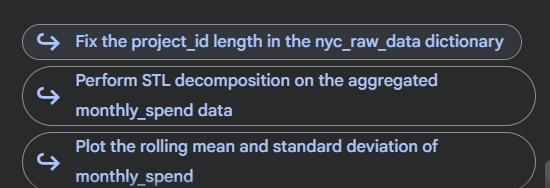

# Answering Report Questions with Initial ML Results:

Based on these initial models, we can start to address some of your report questions:

**Research Question 2: Can we forecast whether a project will exceed its budget or miss its deadline, and by how much?**
*   Our current approach with `is_long_task` demonstrates that we can build models to *forecast whether a task is likely to be long (a proxy for missing a deadline)*. The accuracy and other metrics from the classification report indicate how well our models perform. For 'by how much', we would typically move to a regression task predicting the actual `task_duration_days` or `material_cost_usd`.

**Research Question 3: Which project-level factors most strongly predict cost overruns and schedule delays?**
*   The **Feature Importance plot from the Random Forest Classifier** directly addresses this question. The features with the highest importance scores are the ones that the model found most influential in predicting whether a task would be 'long'. In a real scenario, this would tell you which project characteristics (e.g., `labor_required`, `material_cost_usd`, `resource_constraint_score`, `risk_level_medium`) are critical indicators of potential delays or overruns.

**Next Steps / Brainstorming for further ML:**
*   **Regression for 'by how much':** To answer the 'by how much' part of Research Question 2, we would train regression models to predict `task_duration_days` directly, or if you had actual cost overrun/schedule delay values in your full dataset, predict those.
*   **More Advanced Models:** Experiment with other models from your modules like Support Vector Machines (SVM - Module 8) or more complex ensemble methods.
*   **Cross-validation and Hyperparameter Tuning:** For more robust evaluation and better model performance, implement cross-validation and tune model hyperparameters.
*   **Time-Series Analysis (Module 5):** If your full Kaggle dataset includes actual start dates and progress over time, we could then explore time-series patterns for `task_duration_days` or `material_cost_usd` as mentioned in Research Question 1.
*   **Text Analytics (Module 9):** If your dataset eventually includes project briefs or descriptions, we can integrate LLM-based feature extraction as per Research Question 4.

# Answering Research Question 1: Time-Series Patterns

To answer Research Question 1:

> *"What time-series patterns exist in project spend and milestone completion rates across different project types and phases? (Using STL decomposition, rolling statistics, ACF/PACF analysis)"*

We can utilize the R code already present in cell `QxBLLJ_rEHwD`. This cell provides a comprehensive example of how to perform the requested time-series analyses. Once you have a suitable dataset loaded and processed into a `tsibble` object (as demonstrated with `project_ts` and `ts_example` in the R code), you can perform the following:

1.  **STL Decomposition**: Look at the section with `ts_example %>% model(stl = STL(monthly_spend ~ season(window = "periodic"))) %>% components() %>% autoplot()`. This code breaks down a time series into seasonal, trend, and remainder components, helping to identify underlying patterns.

2.  **Rolling Statistics**: The code block calculating `roll_mean_6` and `roll_sd_6` using `rollapply` demonstrates how to compute rolling averages and standard deviations. This helps smooth out short-term fluctuations and highlight longer-term trends and volatility.

3.  **ACF/PACF Analysis**: The `ts_example %>% ACF(monthly_spend) %>% autoplot()` and `ts_example %>% PACF(monthly_spend) %>% autoplot()` commands will generate Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) plots. These plots are crucial for identifying the presence of seasonality, trend, and appropriate model orders for forecasting models like ARIMA.

4.  **Visualizations**: The R code also includes several relevant visualizations that will help you understand time-series patterns:
    *   `Spend trajectory plots by project type and phase`: Shows how spend evolves over time for different project categories.
    *   `Seasonal subseries plots`: Helps visualize seasonal patterns within the data.
    *   `Rolling cost-overrun rate over time`: Illustrates portfolio-level trends in project performance.

By executing and interpreting the outputs from these sections in cell `QxBLLJ_rEHwD` with your own data, you will be able to identify and describe the time-series patterns requested in Research Question 1.